Dataset shape: (10000, 20)
     N   P    K  Soil_pH  Soil_Moisture Soil_Type  Organic_Carbon  \
0  132  62   22     6.35          59.78      Clay            0.43   
1  122  71   66     5.98          25.54     Sandy            0.65   
2   44  35  104     8.07          25.87     Sandy            0.79   
3  136  96  113     4.83          42.97      Silt            0.45   
4  101  34   42     5.84          48.01      Silt            0.69   

   Temperature  Humidity  Rainfall  Sunlight_Hours  Wind_Speed   Region  \
0        22.97     53.89   1305.68            7.73       15.96  Central   
1        17.00     76.90   1942.05            9.25       12.60    North   
2        25.52     44.78   2216.20            8.50       15.63    North   
3        18.59     31.89    607.18            8.75        5.49     East   
4        22.74     46.27    483.47            8.00        7.44  Central   

   Altitude  Season  Crop_Type Irrigation_Type  Fertilizer_Used  \
0        36    Rabi      Maize          

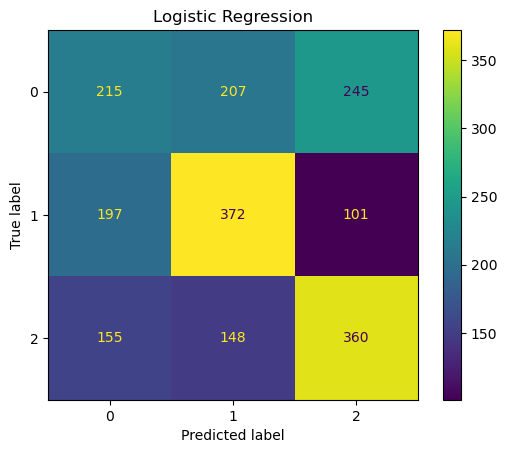


KNN
Train Accuracy: 59.00%
Test Accuracy:  40.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.43      0.38       667
           1       0.45      0.45      0.45       670
           2       0.46      0.33      0.38       663

    accuracy                           0.41      2000
   macro avg       0.41      0.40      0.40      2000
weighted avg       0.41      0.41      0.40      2000



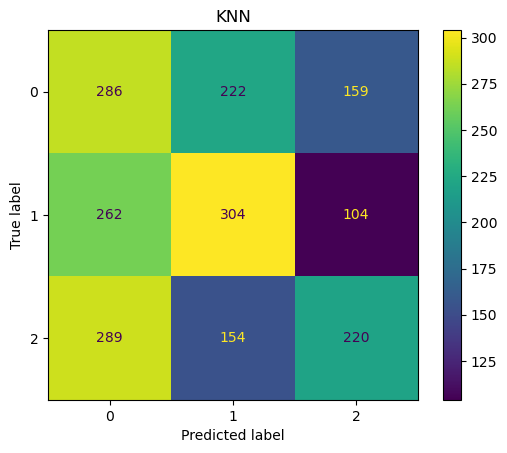


SVM
Train Accuracy: 46.48%
Test Accuracy:  47.60%

Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.07      0.12       667
           1       0.49      0.70      0.58       670
           2       0.49      0.65      0.56       663

    accuracy                           0.48      2000
   macro avg       0.43      0.48      0.42      2000
weighted avg       0.43      0.48      0.42      2000



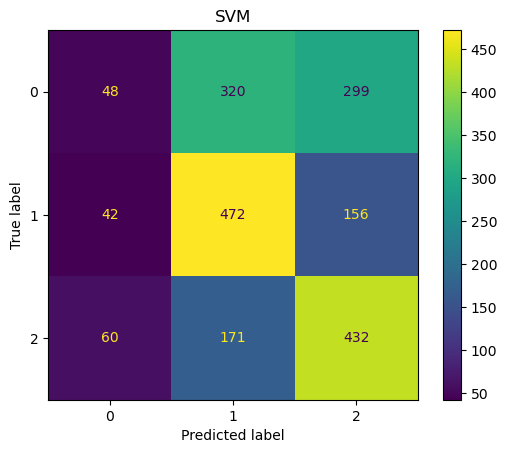


Decision Tree
Train Accuracy: 93.81%
Test Accuracy:  82.90%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       667
           1       0.75      0.75      0.75       670
           2       0.74      0.74      0.74       663

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000



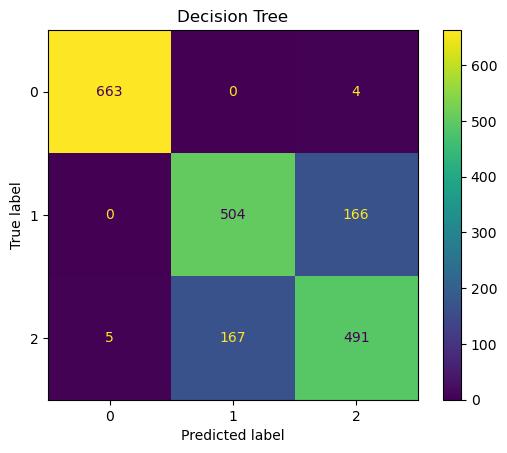


Random Forest
Train Accuracy: 100.00%
Test Accuracy:  85.90%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       667
           1       0.79      0.82      0.80       670
           2       0.81      0.77      0.79       663

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



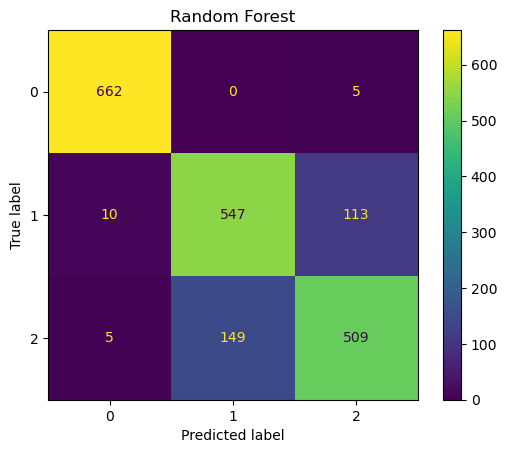


Model Comparison:
                  Model  Train Accuracy  Test Accuracy  Recall  F1-Score
4        Random Forest          100.00          85.90   85.90     85.84
3        Decision Tree           93.81          82.90   82.90     82.89
2                  SVM           46.48          47.60   47.60     41.76
0  Logistic Regression           46.66          47.35   47.35     46.90
1                  KNN           59.00          40.50   40.50     40.50

  REGRESSION RESULTS (R² SCORE)
R² Score: 0.9978
RMSE: 1.1317


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Load dataset
df = pd.read_csv('C:/Users/TARUN KUMAR/Desktop/Datasets/crop-yield.csv')

print(f'Dataset shape: {df.shape}')
print(df.head())

# -------------------------------
# ✅ STEP 1: CREATE YIELD LABEL
# -------------------------------
# Using quantiles (BEST way → balanced classes)

df['Yield_Label'] = pd.qcut(
    df['Crop_Yield_ton_per_hectare'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

print("\nClass Distribution:")
print(df['Yield_Label'].value_counts())

# -------------------------------
# ✅ STEP 2: ENCODE CATEGORICAL DATA
# -------------------------------
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Encode target
df['Yield_Label'] = le.fit_transform(df['Yield_Label'])

# -------------------------------
# ✅ STEP 3: FEATURES & TARGET
# -------------------------------
X = df.drop(['Crop_Yield_ton_per_hectare', 'Yield_Label'], axis=1)
y = df['Yield_Label']

# -------------------------------
# ✅ STEP 4: TRAIN TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTraining set: {X_train.shape[0]} samples')
print(f'Testing set:  {X_test.shape[0]} samples')

# -------------------------------
# ✅ MODEL EVALUATION FUNCTION
# -------------------------------
results = []

def evaluate_model(name, model):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred, average='weighted')
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')

    results.append({
        'Model': name,
        'Train Accuracy': round(train_acc * 100, 2),
        'Test Accuracy': round(test_acc * 100, 2),
        'Recall': round(test_recall * 100, 2),
        'F1-Score': round(test_f1 * 100, 2)
    })

    print(f'\n{name}')
    print(f'Train Accuracy: {train_acc*100:.2f}%')
    print(f'Test Accuracy:  {test_acc*100:.2f}%')

    print('\nClassification Report:')
    print(classification_report(y_test, y_test_pred))

    cm = confusion_matrix(y_test, y_test_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(name)
    plt.show()

# -------------------------------
# ✅ MODELS
# -------------------------------

# Logistic Regression
from sklearn.linear_model import LogisticRegression
evaluate_model('Logistic Regression', LogisticRegression(max_iter=1000))

# KNN
from sklearn.neighbors import KNeighborsClassifier
evaluate_model('KNN', KNeighborsClassifier(n_neighbors=5))

# SVM
from sklearn.svm import SVC
evaluate_model('SVM', SVC())

# Decision Tree
from sklearn.tree import DecisionTreeClassifier
evaluate_model('Decision Tree', DecisionTreeClassifier(max_depth=10))

# Random Forest
from sklearn.ensemble import RandomForestClassifier
evaluate_model('Random Forest', RandomForestClassifier(n_estimators=100))


results_df = pd.DataFrame(results).sort_values(by='Test Accuracy', ascending=False)
print("\nModel Comparison:\n", results_df)


# =========================================================
# ✅ REGRESSION MODEL (for R² Score)
# =========================================================

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Use original target (continuous)
X_reg = df.drop(['Crop_Yield_ton_per_hectare', 'Yield_Label'], axis=1)
y_reg = df['Crop_Yield_ton_per_hectare']

# Train-test split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# (Optional but recommended) Scaling
scaler = StandardScaler()
Xr_train = scaler.fit_transform(Xr_train)
Xr_test = scaler.transform(Xr_test)

# Model
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(Xr_train, yr_train)

# Predictions
yr_pred = rf_reg.predict(Xr_test)

# Metrics
r2 = r2_score(yr_test, yr_pred)
rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))

print('\n' + '='*60)
print('  REGRESSION RESULTS (R² SCORE)')
print('='*60)
print(f'R² Score: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
